# **Identifying the detector Line Spread Function (LSF)**
--- 

The goal was to try to estimate a more accurate explanation of the emission line shape on the detector.

*I will need to look further into literature to see if I should keep an asymetric gaussian or if it might be the sum of two gaussien (Martin et al., 2005)*

- Need to improve final plot to be clearer

## **0. Importing relevant libraries**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Asymetric gaussian function definition**
---

-> Used for LSF fitting

*Might need to consider sum of two gaussian later on instead*

In [2]:
def asymmetric_gaussian(x, A, x0, sigma0, a, y0):
    # sigma varie en fonction de x pour créer la queue d'un côté
    sigma = 2 * sigma0 / (1 + np.exp(a * (x - x0)))
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0

## **2. Averaging laser line captured data (25 captures)**
---

100%|██████████| 25/25 [00:00<00:00, 34.62it/s]


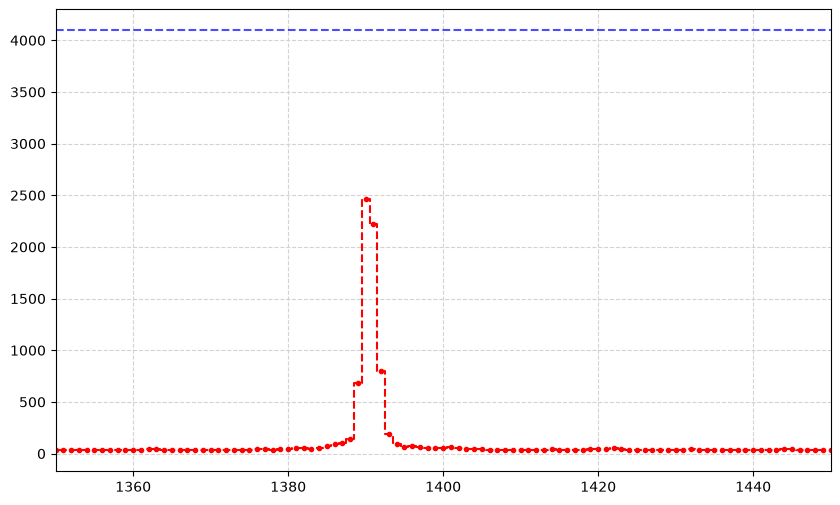

In [10]:
FILES = os.listdir("laser_2/science/SCIENCE") # files containing the 25 laser 200µs captures
MAX_W, MAX_H = 1936, 1216 # detector pixels size
YLINE = 350 # y-line detector chosen for analysis

MASTER_SCIENCE = np.zeros((MAX_H,MAX_W,len(FILES)), dtype=np.float32) 
MASTER_SCIENCE_ERR = np.zeros((MAX_H,MAX_W,len(FILES)), dtype=np.float32)

for i, file in enumerate(tqdm(FILES)):
    with fits.open(f"laser_2/science/SCIENCE/{file}") as hdul:
        MASTER_SCIENCE[:,:,i] = hdul[0].data

data = np.median(MASTER_SCIENCE,axis=2) # final science image considered as the median of each pixel across the z-axis of the dataset
data_err = np.std(MASTER_SCIENCE,axis=2) # count error considered as the standard deviation of the averaged dataset

x = np.arange(1936)
y = data[YLINE]
yerr = 1.2533 * data_err[YLINE,:] / np.sqrt(len(FILES))


fig, ax = plt.subplots(figsize=(10,6))
ax.grid(ls='--',c='lightgrey')
# ax.set_yscale('log')

ax.step(x, y,ls='--',marker='.',color='red',where='mid', linewidth=1.5)
ax.set_xlim(1350,1450)
# ax.set_xlim(1250,1500)
ax.axhline(y=4096,ls='--',color='blue',alpha=0.7)

In [4]:
zone_fond = (x < 1370) | (x > 1420) # noise estimation as everything out of the laser emission line
y0_estime = np.mean(y[zone_fond])
print(f"Valeur estimée du fond continu : {y0_estime:.2f} coups")

Valeur estimée du fond continu : 33.31 coups


In [5]:
def asymmetric_pseudo_voigt(x, A, x0, sigma, gamma_L, gamma_R, y0):
    """
    Un profil hybride (Pseudo-Voigt) qui permet d'avoir des ailes lorentziennes
    des deux côtés, mais avec des largeurs différentes à gauche et à droite.
    """
    # On sépare le côté gauche du côté droit
    gamma = np.where(x < x0, gamma_L, gamma_R)
    
    # Profil de Lorentz (pour les queues qui s'étalent)
    lorentz = (gamma**2) / ((x - x0)**2 + gamma**2)
    
    # Profil Gaussien (pour le cœur du pic)
    gauss = np.exp(-(x - x0)**2 / (2 * sigma**2))
    
    # On mélange les deux (50% Gauss, 50% Lorentz par exemple, ou laisser un paramètre libre)
    return A * (0.5 * gauss + 0.5 * lorentz) + y0

--- Fit results ---
Amplitude (A) : 2672.3
Line center (x0)   : 1390.39
Floor noise (y0)        : 33.7
Asymetry paramter (a): -0.136


/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_53677/65441816.py:3: RuntimeWarning: overflow encountered in exp
  sigma = 2 * sigma0 / (1 + np.exp(a * (x - x0)))
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_53677/65441816.py:4: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_53677/65441816.py:4: RuntimeWarning: overflow encountered in divide
  return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0


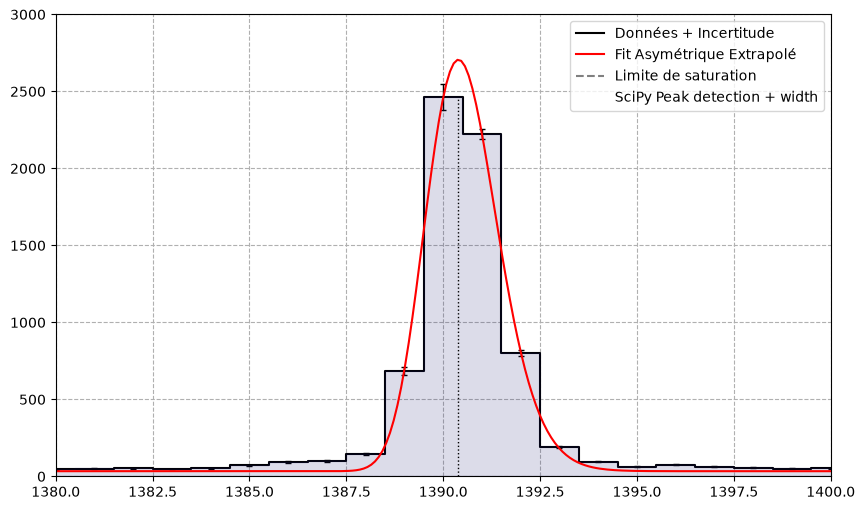

In [19]:
from scipy.optimize import curve_fit

mask = y < 4096 # excluding detector saturation
x_fit = x[mask]
y_fit = y[mask]

# initial LSF asymetric gaussian estimate
A_init = 1000 # peak amplitude
x0_init = 1391 # peak x-center position
sigma0_init = 2 # peak width at base
a_init = 0.5 # asymetry parameter
y0_init = y0_estime # floor noise estimate (previous cell)

p0 = [A_init, x0_init, sigma0_init, a_init, y0_init]

# bounds estimate to avoid weird fit values
# format: ([min_A, min_x0, min_sigma0, min_a, min_y0], [max_A, max_x0, max_sigma0, max_a, max_y0])
bounds = ([200, 1385, 0.1, -2, 0], 
          [10000, 1395, 10, 2, 300])

# curve_fit fitting
popt, pcov = curve_fit(asymmetric_gaussian, x_fit, y_fit, p0=p0, bounds=bounds)

# data extraction
A_opt, x0_opt, sigma0_opt, a_opt, y0_opt = popt

print(f"--- Fit results ---")
print(f"Amplitude (A) : {A_opt:.1f}")
print(f"Line center (x0)   : {x0_opt:.2f}")
print(f"Floor noise (y0)        : {y0_opt:.1f}")
print(f"Asymetry paramter (a): {a_opt:.3f}")



fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    x, y, 
    yerr=5*yerr, # vertical (count) uncertainties (from averaging)
    fmt='none', # because i use step instead
    ecolor='black',
    elinewidth=1,
    capsize=2
)
ax.step(x, y, color='black', where='mid', linewidth=1.5, label='Données + Incertitude')

ax.fill_between(
        x, y, 
        step='mid',          # /!\ DOIT correspondre au 'where' de ton plt.step
        color='midnightblue',   # Une couleur proche de ton bleu marine
        alpha=0.15,          # Très transparent pour ne rien masquer
        zorder=2             # Reste derrière les points de données
)
ax.errorbar(x=x0_opt, y=(y[int(x0_opt)]),color='black',marker='',ls='',lw=1, capsize=3,label='SciPy Peak detection + width',zorder=2)
# ax.plot(peaks[mask], y[peaks][mask], "x")
# ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
# ax.axvline(x=771,ls='--',alpha=0.7)
# ax.axvline(x=780,ls='--',alpha=0.7)

ax.vlines(x=x0_opt, ymin=0, ymax=y[int(x0_opt)], ls=':',lw=1,color='black')


x_fine = np.linspace(x.min(), x.max(), 20000)
ax.plot(x_fine, asymmetric_gaussian(x_fine, *popt), 'r-', label='Fit Asymétrique Extrapolé')

ax.axhline(4095, color='gray', linestyle='--', label='Limite de saturation')
ax.grid(True, linestyle='--')
ax.set_xlim(1380,1400)
# ax.axvline(x0_opt+sigma0_opt/2,ls='--', c='darkgrey',label='1std')
# ax.axvline(x0_opt-sigma0_opt/2,ls='--', c='darkgrey')
# ax.axvline(x0_opt+np.sqrt(2*np.log(2))*sigma0_opt,ls='--', c='darkred',label='FWHM')
# ax.axvline(x0_opt-np.sqrt(2*np.log(2))*sigma0_opt,ls='--', c='darkred')
# ax.axhline(A_opt//2)
plt.ylim(0,3000)
ax.legend()
plt.show()